<a href="https://colab.research.google.com/github/LeonardoFisAct/DSML_Notes/blob/main/Final_HW_Module_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de librerias

Se realizara el uso de algunas librerias que no estan precargadas con Colab. Por ello se instalaran antes de importar.

In [ ]:
# altair para visualizaciones
!pip install -q altair

In [ ]:
#Librerias para manejo de datos y visualizaciones
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import jarque_bera
from scipy import stats
#Librerias para Entrenamiento del Modelo
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Librerias para la Validación del Modelo
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import RepeatedKFold
#Librerias para la Evaluación del Modelo
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn import metrics # para conocer el valor de las métricas

# Carga de Datos

In [ ]:
df = pd.read_csv("breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Descripción de las Variables

`id` : Identificador del diagnóstico.

`diagnosis` :  Diagnóstico (Benigno : B , Maligno : M )  

Un tumor benigno es cuando este sigue generando e imitando células normales que no invaden al organismo.

Un tumor maligno cuando la reproducción celular es descontrolada y desordenada. Entonces estamos ante un cáncer que crece e invade otras zonas del cuerpo.

Diez valores reales son computados para cada nucleo celular (mean,se,worst)

`radius` : Media de las distancias del centro a puntos en el permietro

`texture` Desviación estandar de los valores en escala de grises

`perimeter`: Perimetro del nucleo celular

`area`: Area del nucleo celular

`smoothness`: Variación local en las longitudes de los radios

`compactness`: (perimeter^2 / area - 1.0)

`concavity`: Severidad de las proporciones concavas en el contorno

`concave points`: Numero de proporciones concavas en el contorno

`symmetry`: Simetria del nucelo celular

`fractal dimension`: ("coastline approximation" - 1)

La variable objetivo sera `diagnosis`  y todas las demás seran los atributos a exepción de `id`.

In [ ]:
df.drop(['id'],axis=1,inplace=True)
X = df.drop(['diagnosis'],axis=1)
y = df['diagnosis']

Se realizara un split del 20% de los datos para prueba y el resto para entrenamiento

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# EDA

## Variable objetivo

In [ ]:
y_train.head()

,diagnosis
10,M
170,B
407,B
430,M
27,M


In [ ]:
#verificar valores nulos
y_train.isnull().sum()

np.int64(0)

In [ ]:

alt.Chart(pd.DataFrame(y_train)).mark_bar().encode(
    x='diagnosis',
    y='count()',
).properties(
    width=400,
    height=300,
    title={
        "text": "Conteo de Diagnósticos",
        "subtitle": "Diagnósticos en el conjunto de entrenamiento"
    }
)

alt.Chart(...)

En apariencia no se presenta un desbalanceo de clases.

## Atributos

In [ ]:
#descripción de los atributos de entrenamiento
tab = X_train.describe().T
tab

,count,mean,std,min,25%,50%,75%,max
radius_mean,455.0,14.166077,3.579081,6.981000,11.710000,13.340000,15.935000,28.11000
texture_mean,455.0,19.417692,4.290653,9.710000,16.335000,18.900000,21.830000,39.28000
perimeter_mean,455.0,92.215868,24.717118,43.790000,75.235000,86.180000,104.500000,188.50000
area_mean,455.0,659.578242,360.418686,143.500000,420.400000,546.400000,795.500000,2501.00000
smoothness_mean,455.0,0.095993,0.014310,0.062510,0.085130,0.095240,0.104900,0.16340
compactness_mean,455.0,0.103835,0.053910,0.019380,0.063735,0.092280,0.130350,0.34540
concavity_mean,455.0,0.089184,0.081698,0.000000,0.029520,0.059400,0.132200,0.42680
concave points_mean,455.0,0.049015,0.039686,0.000000,0.019685,0.033340,0.074075,0.20120
symmetry_mean,455.0,0.181497,0.027646,0.106000,0.162050,0.179900,0.195400,0.30400
fractal_dimension_mean,455.0,0.062715,0.006971,0.050240,0.057635,0.061300,0.066370,0.09744


In [ ]:
# agregar asimetria y kurtosis
tab['skewness']=X_train.skew()
tab['kurtosis']=X_train.kurtosis()
tab

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
radius_mean,455.0,14.166077,3.579081,6.981000,11.710000,13.340000,15.935000,28.11000,0.985641,0.996608
texture_mean,455.0,19.417692,4.290653,9.710000,16.335000,18.900000,21.830000,39.28000,0.647329,0.857447
perimeter_mean,455.0,92.215868,24.717118,43.790000,75.235000,86.180000,104.500000,188.50000,1.036747,1.135840
area_mean,455.0,659.578242,360.418686,143.500000,420.400000,546.400000,795.500000,2501.00000,1.720225,4.005636
smoothness_mean,455.0,0.095993,0.014310,0.062510,0.085130,0.095240,0.104900,0.16340,0.576088,0.994066
compactness_mean,455.0,0.103835,0.053910,0.019380,0.063735,0.092280,0.130350,0.34540,1.271003,1.918359
concavity_mean,455.0,0.089184,0.081698,0.000000,0.029520,0.059400,0.132200,0.42680,1.459792,2.177399
concave points_mean,455.0,0.049015,0.039686,0.000000,0.019685,0.033340,0.074075,0.20120,1.203771,1.140856
symmetry_mean,455.0,0.181497,0.027646,0.106000,0.162050,0.179900,0.195400,0.30400,0.738489,1.376670
fractal_dimension_mean,455.0,0.062715,0.006971,0.050240,0.057635,0.061300,0.066370,0.09744,1.258972,2.695913


Se sospecha que la mayoria de las variables no siguen una distribución normal (skewness = 0 y Kurtosis = 3), esto nos siguiere la prescencia de outliers en el dataset.

In [ ]:
#verificar normalidad en los datos.
#from scipy.stats import jarque_bera
p_val = jarque_bera(X_train)[1]
tab['normal']=np.where(p_val>0.05,True,False)
tab

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,normal
radius_mean,455.0,14.166077,3.579081,6.981000,11.710000,13.340000,15.935000,28.11000,0.985641,0.996608,False
texture_mean,455.0,19.417692,4.290653,9.710000,16.335000,18.900000,21.830000,39.28000,0.647329,0.857447,False
perimeter_mean,455.0,92.215868,24.717118,43.790000,75.235000,86.180000,104.500000,188.50000,1.036747,1.135840,False
area_mean,455.0,659.578242,360.418686,143.500000,420.400000,546.400000,795.500000,2501.00000,1.720225,4.005636,False
smoothness_mean,455.0,0.095993,0.014310,0.062510,0.085130,0.095240,0.104900,0.16340,0.576088,0.994066,False
compactness_mean,455.0,0.103835,0.053910,0.019380,0.063735,0.092280,0.130350,0.34540,1.271003,1.918359,False
concavity_mean,455.0,0.089184,0.081698,0.000000,0.029520,0.059400,0.132200,0.42680,1.459792,2.177399,False
concave points_mean,455.0,0.049015,0.039686,0.000000,0.019685,0.033340,0.074075,0.20120,1.203771,1.140856,False
symmetry_mean,455.0,0.181497,0.027646,0.106000,0.162050,0.179900,0.195400,0.30400,0.738489,1.376670,False
fractal_dimension_mean,455.0,0.062715,0.006971,0.050240,0.057635,0.061300,0.066370,0.09744,1.258972,2.695913,False


Al realizar la prueba de normalidad Jarque-Bera podemos corroborar que los datos del conjunto de entrenamiento no tienen una distribución normal. Por lo cual se debe realizar una transformacíon en este para obtener un mejor modelo.

Para algunas variables se realiza un grafico de violin para constatar la presencia de outliers.

In [ ]:
# Source - https://stackoverflow.com/a/71902446
# Posted by joelostblom
# Retrieved 2026-04-09, License - CC BY-SA 4.0

#import altair as alt
#import numpy as np
#import pandas as pd
#from scipy import stats

# NAs are not supported in SciPy's density calculation
y = 'area_mean'

# Compute the density function of the data
dens = stats.gaussian_kde(X_train[y])
# Compute the density value for each data point
pdf = dens(X_train[y].sort_values())

# Randomly jitter points within 0 and the upper bond of the probability density function
density_cloud = np.empty(pdf.shape[0])
for i in range(pdf.shape[0]):
    density_cloud[i] = np.random.uniform(0, pdf[i])
# To create a symmetric density/violin, we make every second point negative
# Distributing every other point like this is also more likely to preserve the shape of the violin
violin_cloud = density_cloud.copy()
violin_cloud[::2] = violin_cloud[::2] * -1

# Append the density cloud to the original data in the correctly sorted order
df_with_density = pd.concat([
    df,
    pd.DataFrame({
        'density_cloud': density_cloud,
        'violin_cloud': violin_cloud
        },
        index=X_train['area_mean'].sort_values().index)],
    axis=1
)

# Visualize using the new Offset channel
alt.Chart(df_with_density).mark_circle().encode(
    x='area_mean',
    y='violin_cloud'
).properties(
    width=700,
    height=300,
    title={
        "text": "Violin Plot of area_mean",
        "subtitle": "Plot showing the precence of outliers"
    }
)

alt.Chart(...)

In [ ]:


y = 'concavity_se'

# Compute the density function of the data
dens = stats.gaussian_kde(X_train[y])
# Compute the density value for each data point
pdf = dens(X_train[y].sort_values())

# Randomly jitter points within 0 and the upper bond of the probability density function
density_cloud = np.empty(pdf.shape[0])
for i in range(pdf.shape[0]):
    density_cloud[i] = np.random.uniform(0, pdf[i])
# To create a symmetric density/violin, we make every second point negative
# Distributing every other point like this is also more likely to preserve the shape of the violin
violin_cloud = density_cloud.copy()
violin_cloud[::2] = violin_cloud[::2] * -1

# Append the density cloud to the original data in the correctly sorted order
df_with_density = pd.concat([
    df,
    pd.DataFrame({
        'density_cloud': density_cloud,
        'violin_cloud': violin_cloud
        },
        index=X_train[y].sort_values().index)],
    axis=1
)

# Visualize using the new Offset channel
alt.Chart(df_with_density).mark_circle().encode(
    x='concavity_se',
    y='violin_cloud'
).properties(
    width=700,
    height=300,
    title={
        "text": "Violin Plot of concavity_se",
        "subtitle": "Plot showing the precence of outliers"
    }
)

alt.Chart(...)

In [ ]:

y = 'fractal_dimension_worst'

# Compute the density function of the data
dens = stats.gaussian_kde(X_train[y])
# Compute the density value for each data point
pdf = dens(X_train[y].sort_values())

# Randomly jitter points within 0 and the upper bond of the probability density function
density_cloud = np.empty(pdf.shape[0])
for i in range(pdf.shape[0]):
    density_cloud[i] = np.random.uniform(0, pdf[i])
# To create a symmetric density/violin, we make every second point negative
# Distributing every other point like this is also more likely to preserve the shape of the violin
violin_cloud = density_cloud.copy()
violin_cloud[::2] = violin_cloud[::2] * -1

# Append the density cloud to the original data in the correctly sorted order
df_with_density = pd.concat([
    df,
    pd.DataFrame({
        'density_cloud': density_cloud,
        'violin_cloud': violin_cloud
        },
        index=X_train[y].sort_values().index)],
    axis=1
)

# Visualize using the new Offset channel
alt.Chart(df_with_density).mark_circle().encode(
    x='fractal_dimension_worst',
    y='violin_cloud'
).properties(
    width=700,
    height=300,
    title={
        "text": "Violin Plot of fractal_dimension_worst",
        "subtitle": "Plot showing the precence of outliers"
    }
)

alt.Chart(...)

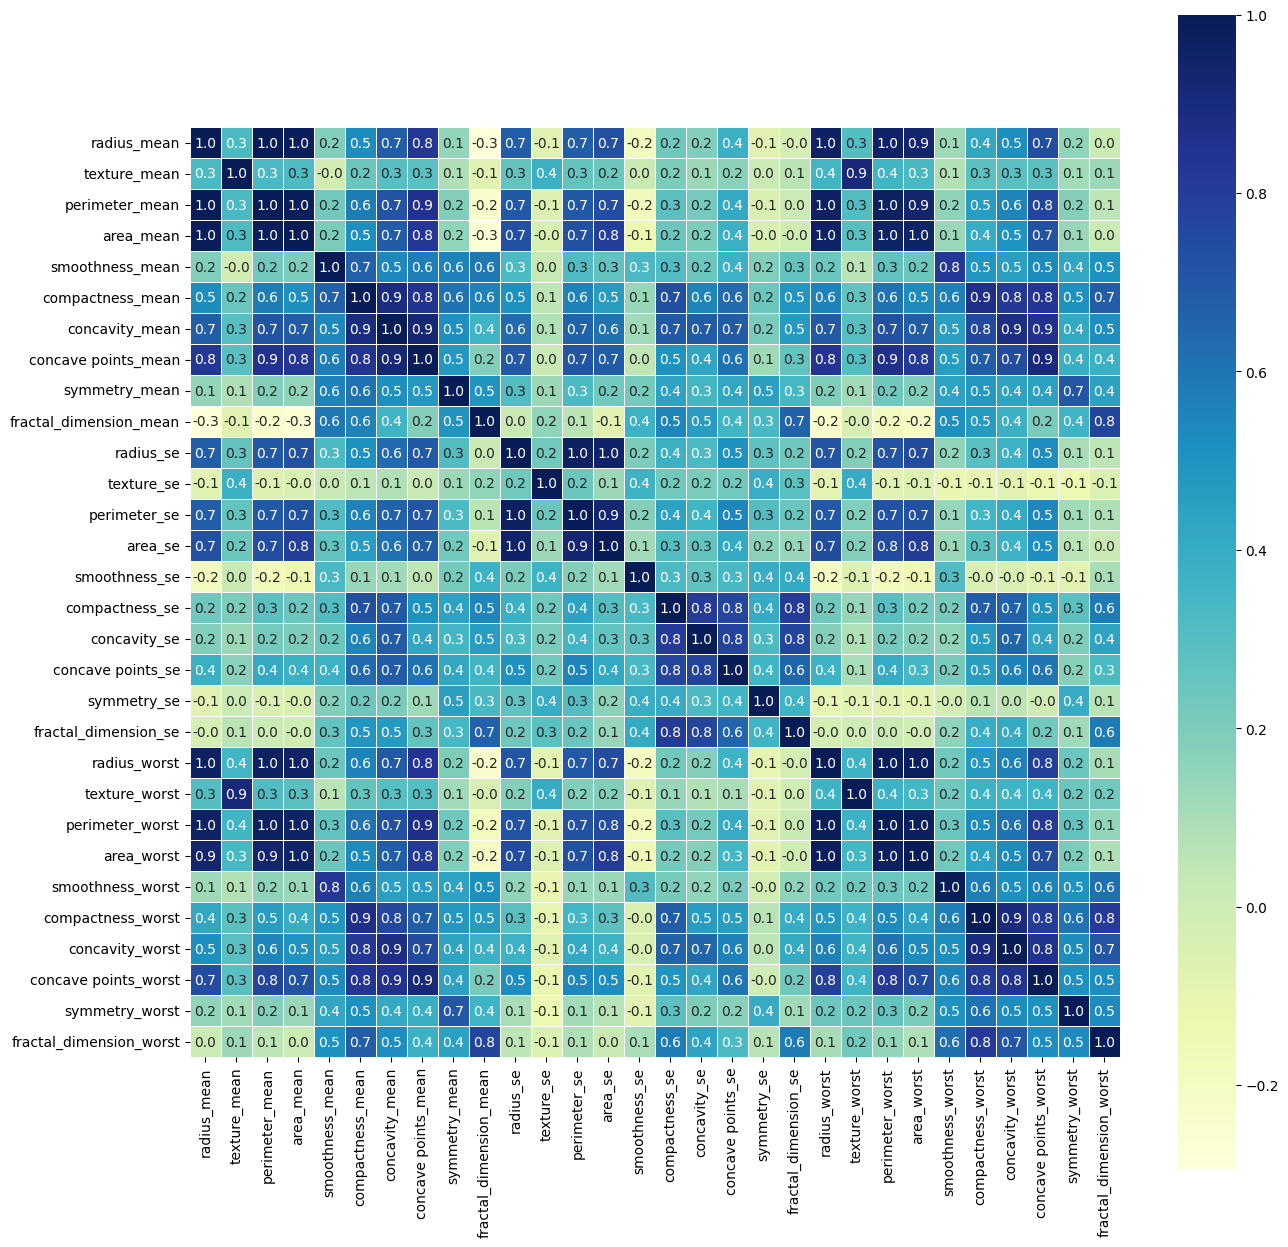

In [ ]:
corr=X_train.corr()
f,ax=plt.subplots(figsize=(15,15))
sns.heatmap(corr,annot=True,linewidths=0.5,fmt=".1f",ax=ax,cmap="YlGnBu",square=True)
plt.show()

Se aprecian clusters con una alta correlación positiva entre las variables `radius_mean`,`perimeter_mean`, `area_mean`,`radius_worst`,`perimeter_worst`, `area_worst`.

Con el uso de un grafico de dispersión se ilustra esta correlación.

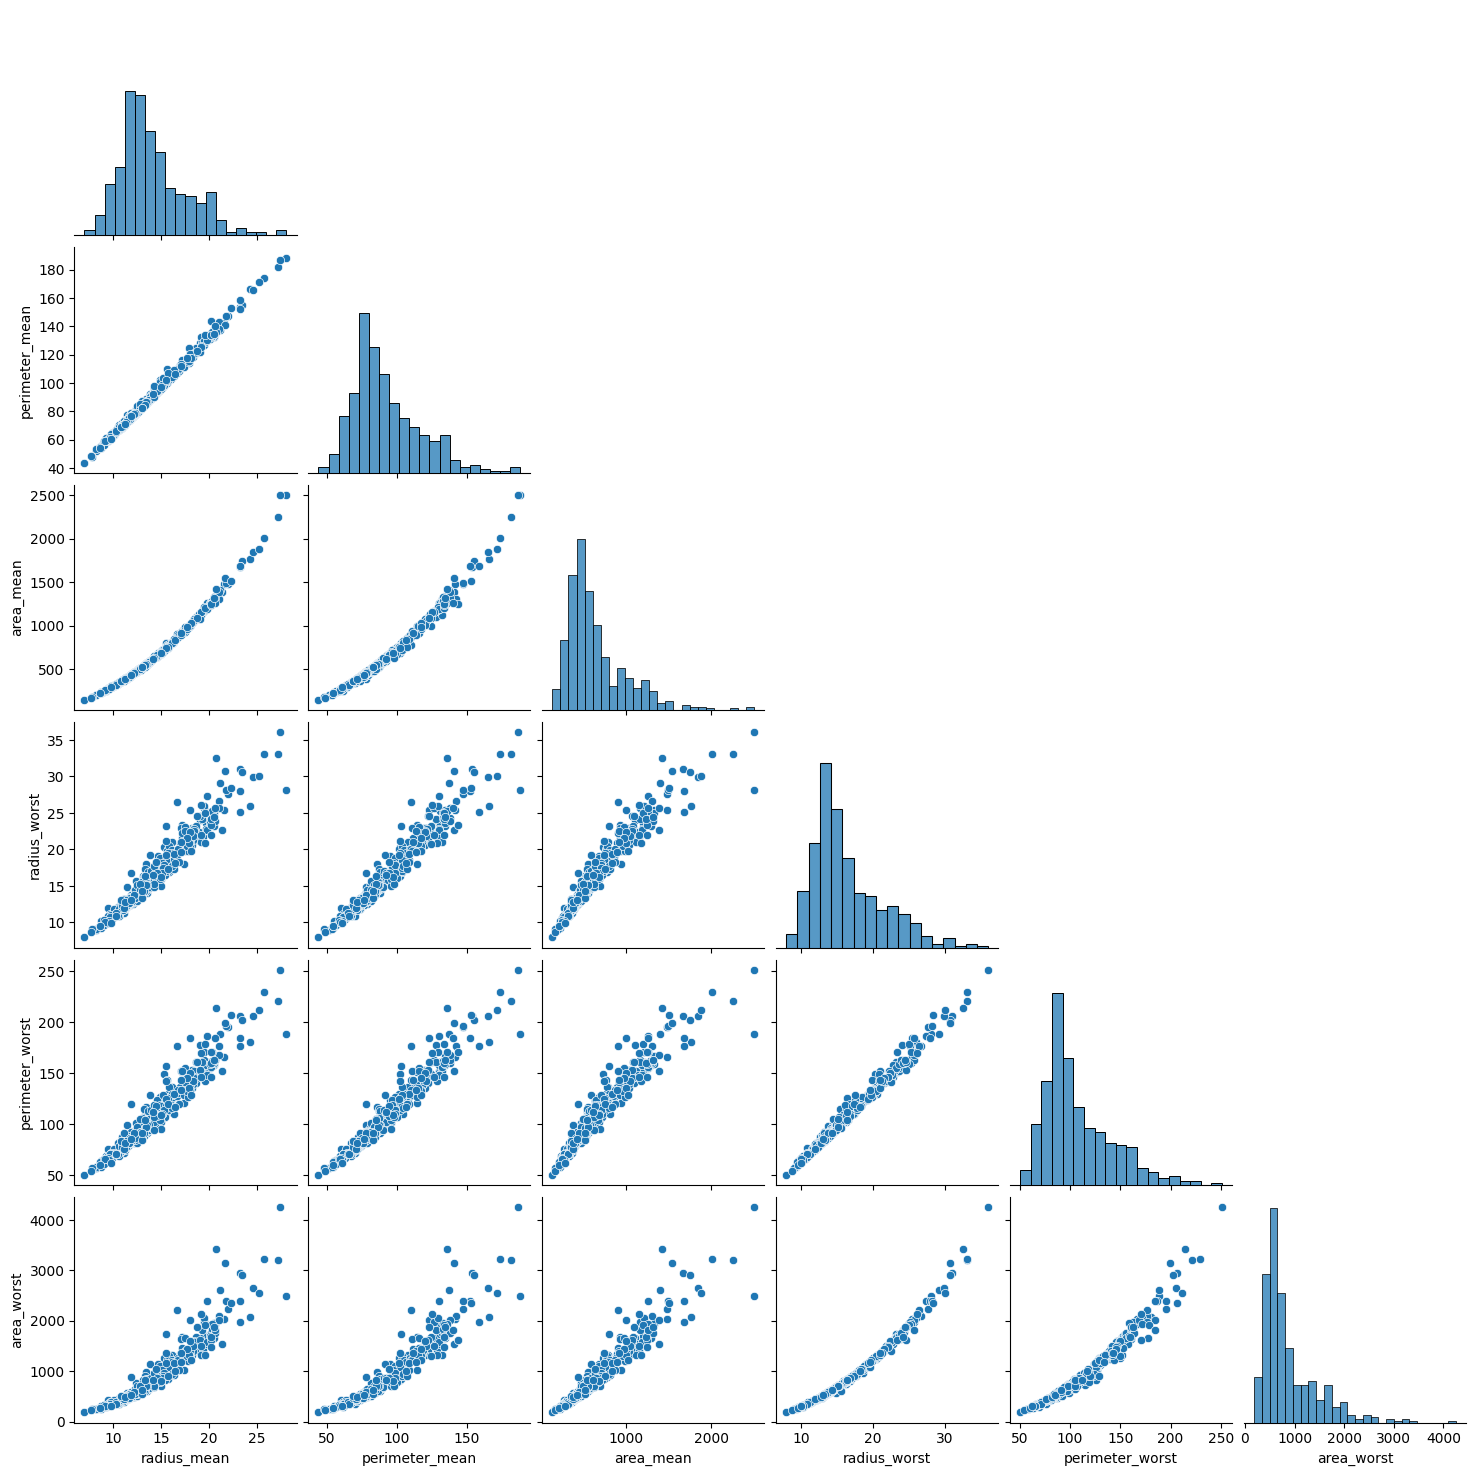

In [ ]:
x_vars = ['radius_mean','perimeter_mean', 'area_mean','radius_worst','perimeter_worst', 'area_worst']
sns.pairplot(X_train,
             x_vars = x_vars,
             y_vars = x_vars,
             corner=True)

Se aprecia la correlación fuerte entre las variables seleccionadas, sugiriendo la precencia de multicolinealidad en el dataset.

Antes de entrenar el modelo se realiza una tranformación a todo el dataset

In [ ]:
#from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_t = scaler.fit_transform(X)
X_t = pd.DataFrame(X_t, columns=X.columns)
X_t.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento del Modelo

Se utilizara un modelo KNN para predecir el tipo de cancer (Benigno o Maligno)

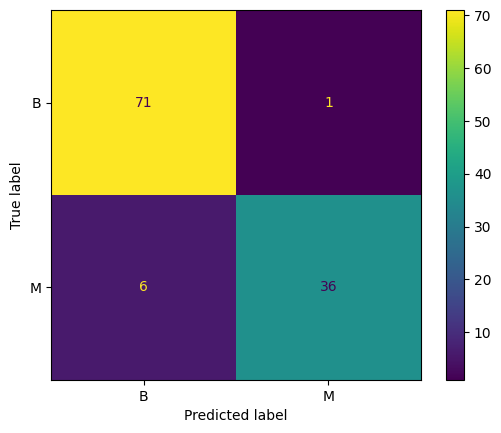

In [ ]:
#Crear y entrenar el modelo KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

#Evaluar el modelo
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=knn.classes_)
disp.plot()
plt.show()

Para este dataset se requiere mejorar la precisión pues se debe identificar de manera correcta los diagnosticos malignos y con k=3 existen 6 diagnosticos malignos que fueron clasificados de manera incorrecta.

In [ ]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           B       0.92      0.99      0.95        72
           M       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



## Validación

### Cross-validation

In [ ]:
#K-Fold

Knn=KNeighborsClassifier(n_neighbors=3, n_jobs=-1).fit(X_train,y_train)

#predicciones=Knn.predict(X_test)


cv=KFold(n_splits=10, random_state=1234, shuffle=True)
# get precision
scores= cross_val_score(Knn, X_t, y, scoring='precision_macro',
                       cv=cv,n_jobs=-1)

print(scores)
scores.mean()
print(f"La precision promedio del modelo:{scores.mean():.4f}")
e2=metrics.precision_score(y_test, y_pred, average='macro')
print(f"La exactitud para el conjunto de entrenamiento es: {e2:.4f}")

[0.9625     0.94444444 0.92094017 1.         0.98717949 0.98571429
 0.98684211 0.97916667 0.98529412 0.9601707 ]
La precision promedio del modelo:0.9712
La exactitud para el conjunto de entrenamiento es: 0.9475


Mejoro cerca de 3 puntos porcentuales la presicion del modelo.

### K-fold repited

In [ ]:
Knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
kfolds_repeated=RepeatedKFold(n_splits=10,n_repeats=10)
# calcular la metrica de desempeño en cada una de las capas de prueba
scores=cross_val_score(Knn,X_t,y,scoring="precision_macro",cv=kfolds_repeated,n_jobs=-1)
# Promedio de exactitud del modelo
print(f"Precision promedio del modelo: {scores.mean():.4f}")

Precision promedio del modelo: 0.9713


### Grid search

In [ ]:
# Creamos el espacio de hiperparámetros para el número de vecinos/k_neighbors
# Definimos un diccionario
espacio_parametros={"n_neighbors":np.arange(1,20)}
# Definimos el modelo, k vecinos
Modelo=KNeighborsClassifier()
# Definimos la validación cruzada
cv=5
# Definimos la rejilla
rejilla=GridSearchCV(Modelo,param_grid=espacio_parametros,cv=cv,scoring="precision_macro",n_jobs=-1)
rejilla.fit(X_t,y)# Definimos la validación cruzada
cv=5
# Definimos la rejilla
rejilla=GridSearchCV(Modelo,param_grid=espacio_parametros,cv=cv,n_jobs=-1)
rejilla.fit(X_t,y)
# Para visualizar la mejor configuración de hiperparámetros (No. de vecinos)
print(f"La mejor configuración de hiperparámetros es: k={rejilla.best_params_}")
# La exactitud el mejor hiperparámetro
print(f"La precisión con el mejor hiperparámetro de vecinos es: {rejilla.best_score_:.4f}")

La mejor configuración de hiperparámetros es: k={'n_neighbors': np.int64(9)}
La precisión con el mejor hiperparámetro de vecinos es: 0.9684


In [ ]:
# Definimos la validación cruzada interna
#cv_interna=KFold(n_splits=10)
cv_interna=RepeatedKFold(n_splits=10,n_repeats=10, random_state=1234)

# Definimos la validación cruzada exterior
#cv_exterior=KFold(n_splits=10)
cv_exterior=RepeatedKFold(n_splits=10,n_repeats=10, random_state=1234)

# Realizamos la búsqueda de la mejor configuración
rejilla_f=GridSearchCV(Modelo,param_grid=espacio_parametros,cv=cv_interna,scoring="precision_macro",n_jobs=-1)
rejilla_f.fit(X_t,y)
print(f"La mejor configuración del hiperparámetro, k =: {rejilla_f.best_params_}")

La mejor configuración del hiperparámetro, k =: {'n_neighbors': np.int64(11)}


In [ ]:
# Paso 12
# Obtener la métrica de la mejor configuración
scores=cross_val_score(rejilla_f,X_t,y,cv=cv_exterior,scoring="precision_macro",n_jobs=-1)
# Paso 13
# Imprimir la métrica final (la realista)
print(f"El desempeño predictivo promedio del mejor modelo es: {scores.mean():.4f}")

El desempeño predictivo promedio del mejor modelo es: 0.9686


El mejor resultado en la precisión fue para un hiperparamétro k = 9.

# Resultados

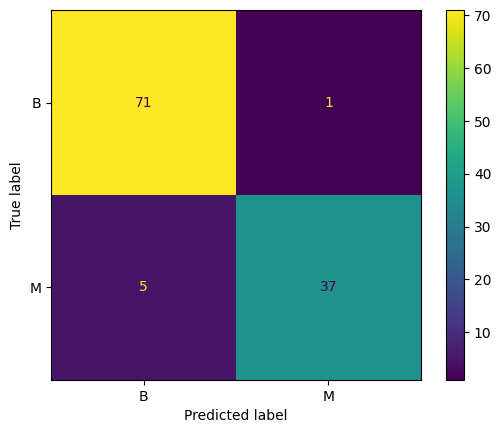

In [ ]:
#Crear y entrenar el modelo KNN
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

#Evaluar el modelo
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=knn.classes_)
disp.plot()
plt.show()

El modelo con K=9 clasifica incorrectamente a 5 casos donde el tumor es maligno. Realiza una clasificasión correcta de clases de 71 para Beningno y 37 para Maligno y solo clasifica incorrectamente a un caso Beningno como Maligno.  

In [ ]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           B       0.93      0.99      0.96        72
           M       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



Este modelo presenta una presicion para los diagnísticos malignos de un 97%, a pesar de ser alto lo ideal seria que fuera de un 100%.

Se realiza un mapa de correlación entre `diagnosis` y los atributos.

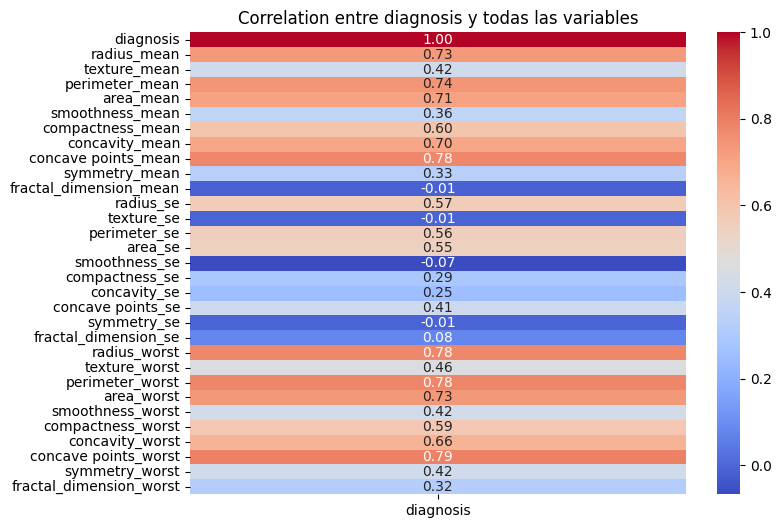

In [ ]:
mapping = {'M': 1, 'B': 0}
df['diagnosis'] = df['diagnosis'].map(mapping)
correlation_matrix = df.corr()
diabetes_related_corr = correlation_matrix[['diagnosis']]
plt.figure(figsize=(8, 6))
sns.heatmap(diabetes_related_corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation entre diagnosis y todas las variables')
plt.show()

Las variables del tipo worst parecen ser los mejores predictores para el modelo. Se utilizara la variable `radius_worst` y `concave_points_worst` para visualizar las predicciones.

In [ ]:
y_prob = knn.predict_proba(X_test)
#y_prob.shape[0]
#max(y_prob[0])
prob = []
for i in range(y_prob.shape[0]):
    prob.append(max(y_prob[i]))

prob

test_data = X_test.copy()
test_data['diagnosis'] = y_test
test_data['pred'] = y_pred
test_data['correct'] = np.where(test_data['diagnosis'] == test_data['pred'], test_data['diagnosis'], "Incorrecto")
test_data['prob'] = prob
test_data

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis,pred,correct,prob
120,-0.771749,-1.970944,-0.767334,-0.715545,-0.187185,-0.710510,-0.673942,-0.585243,-0.527994,-0.236401,...,0.983301,-0.097107,-0.297391,-0.381064,0.186440,0.071164,B,B,B,1.000000
250,1.934906,0.993739,1.933096,2.016784,0.308838,1.066192,2.290035,2.117192,1.436213,-0.541186,...,-0.493969,0.400354,2.048118,1.460136,0.364396,-0.302339,M,M,M,1.000000
375,0.580158,-0.749234,0.590295,0.380003,0.173624,0.747807,-0.279842,0.130282,0.651260,0.414279,...,-0.388763,0.004675,-0.291634,0.159785,0.408076,0.313331,B,B,B,1.000000
99,0.083133,0.111781,0.103427,-0.035236,0.082532,0.184948,0.063788,0.244291,0.246006,0.156275,...,0.470421,0.307478,0.226498,0.637900,-0.295659,0.531115,M,B,Incorrecto,0.888889
455,-0.212241,2.659920,-0.231861,-0.277838,-0.278277,-0.570079,-0.760948,-0.419904,-1.594070,-0.373909,...,-0.664929,-0.713526,-0.969860,-0.563022,-1.140140,-0.398762,B,B,B,0.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,-0.876835,-1.014519,-0.877311,-0.802575,-1.173538,-0.635841,-0.669674,-0.726852,0.698723,-0.047860,...,-1.002465,-0.356652,-0.560775,-0.716658,0.487347,-0.613775,B,B,B,1.000000
534,-0.899556,-0.388538,-0.872369,-0.822768,0.036274,-0.129268,-0.454105,-0.542683,-0.703240,0.181792,...,0.457270,-0.020770,-0.287316,-0.243568,-0.989687,-0.064605,B,B,B,1.000000
448,0.114375,0.011717,0.093953,0.013683,-0.888165,-0.499201,-0.007901,-0.507346,-1.236277,-0.756662,...,-1.028767,0.067653,0.507153,-0.284223,-0.695250,-0.516244,B,B,B,0.777778
205,0.281943,-0.607283,0.280545,0.175512,-0.540877,-0.160348,-0.166973,-0.209683,-0.794513,-0.416437,...,0.733436,0.501500,0.290305,0.161307,0.831934,0.745575,M,B,Incorrecto,0.888889


In [ ]:
alt.Chart(test_data).mark_circle(size=60).encode(
    x='radius_worst',
    y='concave points_worst',
    color='correct',
    tooltip=['diagnosis', 'pred', 'prob', 'correct']
).properties(
    width=700,
    height=300,
    title={
        "text": "Grafico de Dispersión",
        "subtitle": "Visualización de las predicciones"
    }
).interactive()

alt.Chart(...)

#Conclusiones

Es probable que debido a la prescencia de multicolinealidad en los atributos el desempeño del modelo se vea afectado.

Con un hiperparametro de k=  se mejoro de manera significativa la presicion del modelo, lo cual proporciona una mayor confiabilidad en la detección de tumores malignos. A pesar de que mejoro en la clasificacion correcta de tumores malignos aun quedaron algunos falsos positivos, para evitar esto es recomendable utilzar otro modelo de clasificación mas robusto.


# Save to html

In [ ]:
!pip --q install nbconvert

In [ ]:
!jupyter nbconvert --to html /content/Final_HW_Module_1.ipynb

[NbConvertApp] Converting notebook /content/Final_HW_Module_1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 3090922 bytes to /content/Final_HW_Module_1.html
